# Add your own class

[This note-book is in oceantracker/tutorials_how_to/]

First create your own class create as a python file  in the same diretory as your run script. Your class must in import the base case for the role it performs or one of its children in that role.


<div> <embed src="my_part_prop.py"> </div>

 

prelim:     Starting package set up
helper: ----------------------------------------------------------------------
helper: Starting OceanTracker helper class,  version 0.50.03.0100-2025-08-13 
helper:      Python version: 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:45:41) [GCC 13.3.0]
helper: ----------------------------------------------------------------------
helper: OceanTracker version 0.50.03.0100-2025-08-13  starting setup helper "main.py":
helper: Output is in dir "/mnt/c/Users/Laurin.Steidle/OneDrive - Cawthron/Documents/projects/oceantracker_dev/oceantracker/tutorials_how_to/output/minimal_example"
helper:     hint: see for copies of screen output and user supplied parameters, plus all other output
helper:     >>> Note: to help with debugging, parameters as given by user  are in "minimal_example_raw_user_params.json"
helper: ----------------------------------------------------------------------
helper: Numba setup: applied settings, max threads = 8, physical co

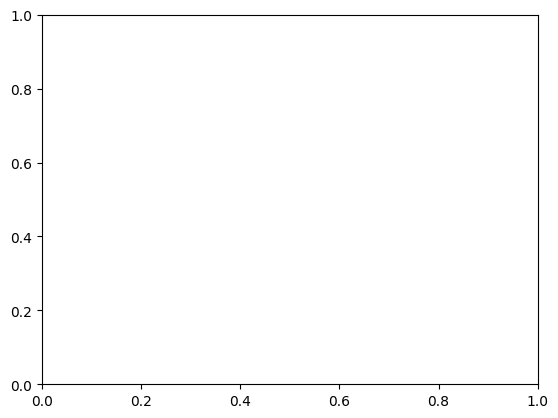

In [1]:
# minimal_example.py using class helper method
#------------------------------------------------
from oceantracker.main import OceanTracker

# make instance of oceantracker to use to set parameters using code, then run
ot = OceanTracker()

# ot.settings method use to set basic settings
ot.settings(output_file_base='minimal_example', # name used as base for output files
            root_output_dir='output',             #  output is put in dir   'root_output_dir'\\'output_file_base'
            time_step= 120. #  2 min time step as seconds
            )
# ot.set_class, sets parameters for a named class
ot.add_class('reader',input_dir= './demo_hindcast/schsim3D',  # folder to search for hindcast files, sub-dirs will, by default, also be searched
                      file_mask=  'demo_hindcast_schisim3D*.nc')  # hindcast file mask
# add  release locations from two points,
#               (ie locations where particles are released at the same times and locations)
# note : can add multiple release groups
ot.add_class('release_groups', 
                    points= [[1595000, 5482600],        #[x,y] pairs of release locations
                             [1599000, 5486200]],      # must be an N by 2 or 3 or list, convertible to a numpy array
                    release_interval= 3600,           # seconds between releasing particles
                    pulse_size= 10,                   # number of particles released each release_interval
            )

# add user written particle property in same dir as notebook

ot.add_class('particle_properties',name='on_bottom_time',
                                        class_name='my_part_prop.TimeAtStatus')

# run oceantracker
case_info_file_name = ot.run()

# output now in folder output/minimal_example
# case_info_file_name the name a json file with useful info for post processing, eg output file names
print(case_info_file_name)


## Read and plot output

  A first basic plot of particle tracks

Merging rectangular track files
	 Reading rectangular track file "minimal_example_tracks_rectangular_000.nc"
dict_keys(['particles_written_per_time_step', 'time_step_range', 'time', 'num_part_released_so_far', 'x', 'x0', 'status', 'status_last_good', 'age', 'ID', 'IDrelease_group', 'user_release_groupID', 'IDpulse', 'hydro_model_gridID', 'time_released', 'on_bottom_time', 'water_depth', 'tide', 'dry_cell_index', 'grid', 'particle_status_flags', 'particle_release_groups', 'axis_lim'])


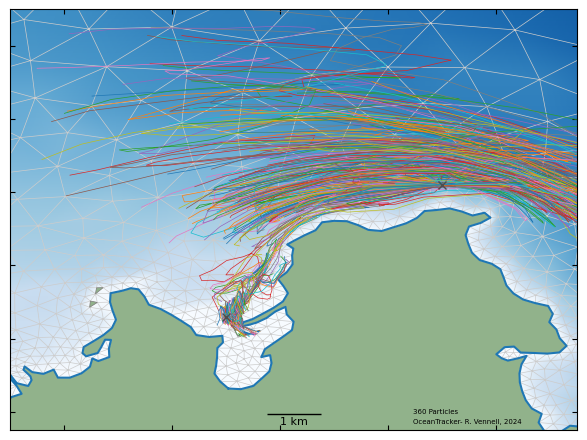

In [2]:
from oceantracker.read_output.python import load_output_files

# read particle track data into a dictionary using case_info_file_name
tracks = load_output_files.load_track_data(case_info_file_name)
print(tracks.keys()) # show what is in tracks dictionary holds

from oceantracker.plot_output import plot_tracks

ax= [1591000, 1601500, 5479500, 5491000]  # area to plot 
plot_tracks.plot_tracks(tracks, axis_lims=ax, show_grid=True)